[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftacf/blob/main/notebook/pastas_vs_nufftacf_regular.ipynb)

# ACF for regularly-sampled signals: Pastas vs nufftacf

This notebook demonstrates the classic-FFT fast path of `nufftacf` for
**regularly-sampled** series: `compute_acf_regular_fft`,
`compute_acf_rectangle_fft`, and `compute_acf_gaussian_fft` (see
`src/nufftacf/fft_acf.py`), on five synthetic signal types:
sine, noisy sine, noisy exponential decay  and square wave.

For the **irregularly-sampled** case (NUFFT path) see
`notebook/pastas_vs_nufftact.ipynb`.

In [ ]:
!pip install -q "nufftacf[benchmark] @ git+https://github.com/jecampagne/nufftacf.git"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.8/181.8 kB 18.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pastas as ps

from nufftacf import (
    compute_acf_regular_fft,
    compute_acf_rectangle_fft,
    compute_acf_gaussian_fft,
)

import nufftacf
print(f'nufftacf : {nufftacf.__version__}')
print(f'pastas    : {ps.__version__}')


nufftacf : 0.1.0
pastas    : 1.14.0


In [3]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})

## Test series

Five synthetic signal types on a regular daily grid.

In [4]:
def generate_series(n_days: int, signal_type: str = "sinus", **params) -> pd.Series:
    """Generate a regularly-sampled (delta_t=1 day) series.

    signal_type: one of "sinus", "noisy sinus", "noisy exponential", "constant", "square".
    """
    t = np.arange(n_days, dtype=float)
    if signal_type == "sinus":
        f = params.get("f", 1.0 / (n_days / 10))
        data = np.sin(2 * np.pi * f * t)
    elif signal_type == "noisy sinus":
        f = params.get("f", 1.0 / (n_days / 10))
        rng = np.random.default_rng(params.get("seed", 0))
        data = np.sin(2 * np.pi * f * t) + rng.standard_normal(n_days) * 0.1
    elif signal_type == "noisy exponential":
        tau_0 = params.get("tau_0", n_days / 5)
        rng = np.random.default_rng(params.get("seed", 0))
        data = np.exp(-t / tau_0) +  rng.standard_normal(n_days) * 0.1
    elif signal_type == "square":
        f = params.get("f", 1.0 / (n_days / 10))
        data = np.sign(np.sin(2 * np.pi * f * t))
    else:
        raise ValueError(f"Unknown signal_type {signal_type!r}")
    idx = pd.date_range("2000-01-01", periods=n_days, freq="D")
    return pd.Series(data=data, index=idx, name=f"STS_{signal_type}")


SIGNAL_TYPES = ["sinus", "noisy sinus", "noisy exponential", "square"]
N_days = 3650


## Pastas vs nufftacf comparison

For each signal type, the ACF is computed with Pastas and with `nufftacf` (FFT path)
for all three bin methods (`regular`, `rectangle`, `gaussian`), then overlaid.

In [ ]:
FFT_FUNCS = {
    "regular"  : compute_acf_regular_fft,
    "rectangle": compute_acf_rectangle_fft,
    "gaussian" : compute_acf_gaussian_fft,
}


def compute_comparison(sts: pd.Series, lags_max: int = 365, bin_width: float = 0.5):
    """Compute Pastas and nufftacf (fft) for all three bin methods on one series."""
    lags = np.arange(0.0, lags_max + 1.0)
    t = (sts.index - sts.index[0]) / pd.Timedelta(days=1)
    t = t.to_numpy(dtype=float)
    x = sts.to_numpy()

    out = {}
    for method in ["regular", "rectangle", "gaussian"]:
        t0 = time.time()
        acf_pastas = ps.stats.acf(
            sts, lags=lags, bin_method=method, bin_width=bin_width, min_obs=0
        )
        dt_pastas = time.time() - t0

        func = FFT_FUNCS[method]
        t0 = time.time()
        if method == "regular":
            c, b = func(lags, t, x)
        else:
            c, b = func(lags, t, x, bin_width=bin_width)
        dt_fft = time.time() - t0

        out[method] = dict(
            pastas_lags=acf_pastas.index.days.to_numpy(),
            pastas_c=acf_pastas.to_numpy(),
            fft_lags=lags,
            fft_c=c,
            t_pastas=dt_pastas,
            t_fft=dt_fft,
        )
    return out


In [6]:
results = []

for signal_type in SIGNAL_TYPES:
    try:
        sts = generate_series(N_days, signal_type)
        print(f"--- {signal_type} (N={N_days}) ---")

        out = compute_comparison(sts)
        # save
        results.append({
            "out": out,
            "sts": sts,
            "signal_type": signal_type,
            "N_days": N_days
        })

    except Exception as e:
        print(f"  ERROR for {signal_type}: {e}")
        continue

--- sinus (N=3650) ---
--- noisy sinus (N=3650) ---
--- noisy exponential (N=3650) ---
--- square (N=3650) ---


# Plots

In [7]:
def plot_comparison_with_series(sts, out: dict, title: str):

    fig = plt.figure(figsize=(7, 6),constrained_layout=True)
    outer = GridSpec(
          2, 1,
          figure=fig,
          height_ratios=[1.2,3.5]
    )

    # ------------------------------------------------------------------
    # Temporal series
    # ------------------------------------------------------------------
    ax_series = fig.add_subplot(outer[0])

    if hasattr(sts, "index"):
        ax_series.scatter(
            sts.index,
            sts,
            s=0.5,
            color="tab:blue",
            label=title,
        )
    else:
        ax_series.plot(
            sts,
            color="black",
            lw=1.2,
            label=title,
        )

    ax_series.set_ylabel("Value")
    ax_series.grid(alpha=0.3)
    ax_series.legend(loc="upper right")

    # ------------------------------------------------------------------
    # Bloc  Auto Correlation Function
    # ------------------------------------------------------------------

    inner = outer[1].subgridspec(
      3, 1,
      hspace=0.,
      )

    methods = ["regular", "rectangle", "gaussian"]

    axes = []

    for i, method in enumerate(methods):

        ax = fig.add_subplot(
            inner[i],
            sharex=axes[0] if axes else None
        )

        axes.append(ax)

        r = out[method]

        ax.plot(
            r["pastas_lags"],
            r["pastas_c"],
            color="tab:blue",
            lw=2,
            label=f"Pastas ({r['t_pastas']*1000:.1f} ms)",
        )

        ax.plot(
            r["fft_lags"],
            r["fft_c"],
            "--",
            color="tab:red",
            lw=2,
            label=f"FFT ({r['t_fft']*1000:.2f} ms)",
        )
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=15))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase=False))

        ax.set_ylabel("ACF")
        if "exponential" in title.lower():
          ax.set_ylim([0.0,1.1])
        else:
          ax.set_ylim([-1.1,1.1])

        ax.text(
            0.01,
            0.2,
            method,
            transform=ax.transAxes,
            fontsize=12,
            weight="bold",
            va="top",
        )

        ax.grid(alpha=0.3)

        if i < 2:
            ax.tick_params(labelbottom=False)

        if i != 2:
            ax.spines["bottom"].set_visible(False)

        if i != 0:
            ax.spines["top"].set_visible(False)

        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3, which="both")  # Affiche la grille pour les ticks majeurs et mineurs

    axes[-1].set_xlabel("Lag")

    plt.show()

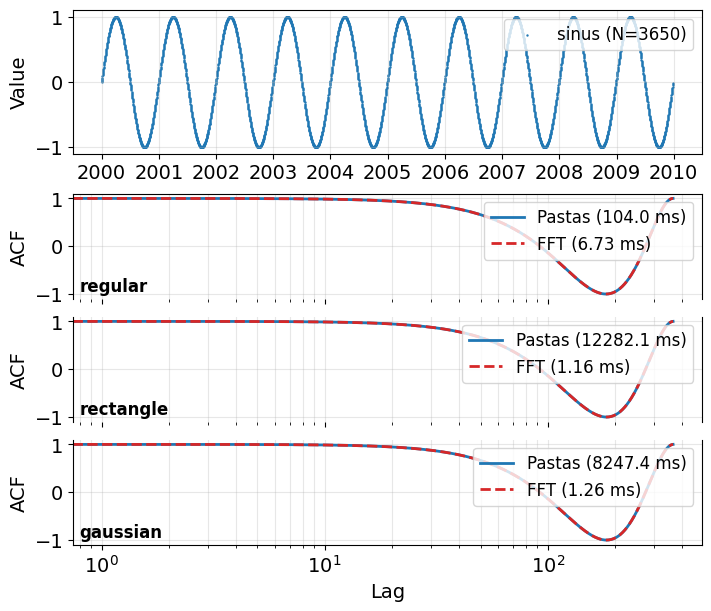

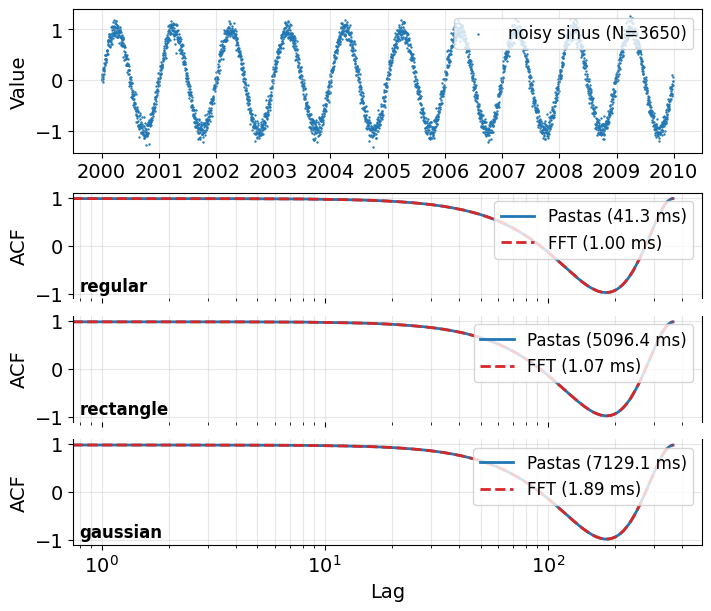

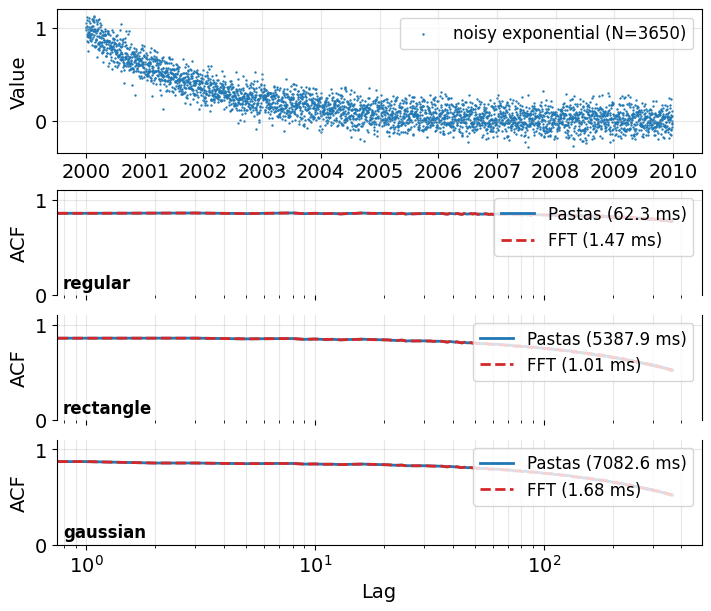

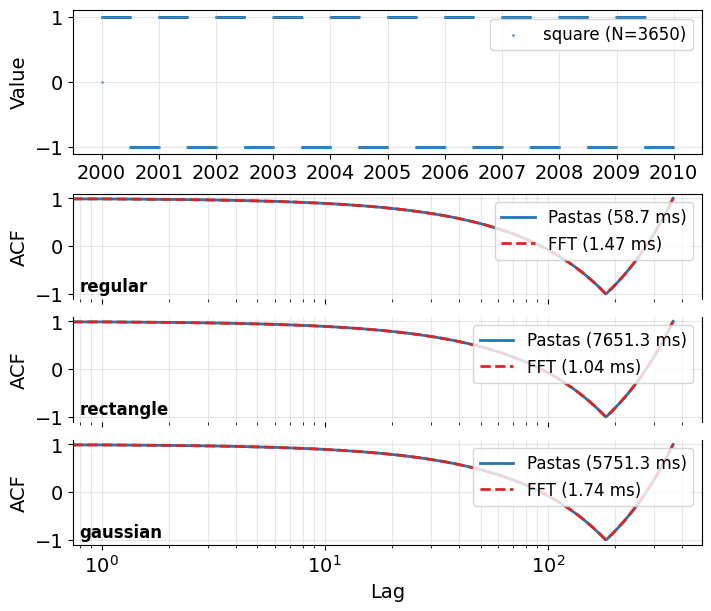

In [8]:
for result in results:
    plot_comparison_with_series(
        sts=result["sts"],
        out=result["out"],
        title=f"{result['signal_type']} (N={result['N_days']})"
    )